In [31]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import random
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split



In [32]:
class RobustBiLSTM(nn.Module):
    """
    - Capture both past and future contextual information (Bidirectional)
    - Learn hierarchical temporal representations (Stacked LSTM)
    - Reduce overfitting using Dropout (Regularization)
    - Avoid unnecessary computation on padding tokens
    - Handle variable-length sequences efficiently
    """
    
    def __init__(self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_layers: int,
        num_classes: int,
        dropout: float = 0.5):
        """
        vocab_size :   Number of tokens in vocabulary
        embedding_dim : Dimensionality of token embeddings
        hidden_dim :   Number of hidden units in each LSTM direction
        num_layers :   Number of stacked LSTM layers
        num_classes :  Number of output classes for sequence classification
        dropout :      Dropout probability for regularization
        """
        super().__init__()
        
        
        
        """
        Calling super().init() initializes the parent nn.Module class, enabling parameter 
        registration, autograd, and proper model behavior during training.
        """
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Embedding layer converts token indices into dense vectors
        # padding_idx=0 ensures that padding tokens do not affect learning
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        
        self.lstm = nn.LSTM(input_size = embedding_dim,
                            hidden_size = hidden_dim,
                            num_layers = num_layers,
                            batch_first = True,
                            bidirectional = True, # bidirectional=True ensures that the model processes the sequence in both forward and backward directions.
                            dropout = dropout if num_layers > 1 else 0 # dropout is applied between LSTM layers
                            )
        
        self.dropout = nn.Dropout(dropout)
        
        #self.fc = nn.Linear(hidden_dim * 2, num_classes) # Fully Connected layer for sequence classification
        # BiLSTM outputs hidden_dim * 2 features (forward + backward)
        
        self.fc = nn.Sequential(
    nn.Linear(hidden_dim * 2, hidden_dim),
    nn.ReLU(),
    nn.Dropout(dropout),
    nn.Linear(hidden_dim, num_classes)
)

        
    def forward (self, x: torch.Tensor, length: torch.Tensor, hidden=None) -> torch.Tensor:
        """
        Forward pass of the model

        x : Padded input tensor of shape:
            (batch_size, max_sequence_length, input_dim)

        lengths : True lengths of each sequence before padding
            Shape: (batch_size,)

        Returns
        logits :  Output logits for sequence classification
            Shape: (batch_size, num_classes)
        """
        x = self.embedding(x)
        packed_input = pack_padded_sequence(x, 
                                            length.cpu(),
                                            batch_first = True,
                                            enforce_sorted = False
                                            )
        """
        This operation removes padding tokens from computation.
            - No unnecessary computation on padding
            - No gradient noise from padded positions
            - Faster and more memory-efficient training
        """
        
        
        packed_output , (h_n, c_n) = self.lstm(packed_input)
        
        """ The hidden state hₙ represents the final output of the LSTM and 
        summarizes the sequence, while the cell state cₙ stores long-term 
        memory and enables stable gradient flow. 
        
        For a Bidirectional LSTM:
          - h_n[-2] → last layer, forward direction
          - h_n[-1] → last layer, backward direction
        """
        
        
        # Unpack the sequence (not used here). The model uses the final hidden states
        # (h_n) as the sequence representation instead of the full LSTM outputs.
        output, output_lengths = pad_packed_sequence(packed_output, batch_first=True)
        
        # hidden state_n -> (num_layers * num_directions, batch_size, hidden_dim)
        # cell state_n -> (num_layers * num_directions, batch_size, hidden_dim)
        
        h_forward = h_n[-2,:,:]
        h_backward = h_n[-1,:,:]
        
        
        #Concatenate forward and backward hidden states
        #This creates a complete sequence representation containing both past and future context.
        h_final = torch.cat((h_forward, h_backward), dim = 1) # (batch_size, hidden_dim * 2)
        
        h_final = self.dropout(h_final)
        logits = self.fc(h_final)
        
        return logits, (h_n, c_n)
        

In [33]:
def generate_balanced_symmetric_dataset(
    num_samples: int = 8000,
    positive_ratio: float = 0.6,
    vocab_size: int = 60,
    min_half_len: int = 3,
    max_half_len: int = 7,
    noise_len: int = 1,
    seed: int = 42
):
    """
    Generate a synthetic sequence classification dataset with controllable class balance.

    The dataset is designed for sequence similarity classification:
        - Class 1 (Positive): Right half is approximately the reverse of the left half
        - Class 0 (Negative): Right half is random (dissimilar)

    Each sequence structure:
        [ left | noise | right ]


    Parameters
    num_samples : int
        Total number of sequences to generate.

    positive_ratio : float
        Proportion of positive (symmetric) samples.
        Example:
            0.5 → 50% positive / 50% negative
            0.6 → 60% positive / 40% negative

    vocab_size : int
        Number of unique tokens in vocabulary.
        Token index 0 is reserved for padding (not used here).

    min_half_len : int
        Minimum length of the left (and right) segment.

    max_half_len : int
        Maximum length of the left (and right) segment.

    noise_len : int
        Number of random tokens inserted between left and right segments.

    seed : int
        Random seed for reproducibility.


    Returns
    sequences : List[torch.Tensor]
        List of variable-length sequences.

    labels : torch.Tensor
        Tensor of shape (num_samples,) containing class labels (0 or 1).
    """


    random.seed(seed)
    torch.manual_seed(seed)

    sequences = []
    labels = []

    for _ in range(num_samples):

        # Randomly choose length of left half
        half_len = random.randint(min_half_len, max_half_len)

        # Generate left segment (avoid token 0 since it is padding)
        left = torch.randint(1, vocab_size, (half_len,))

        # Generate small random noise segment
        noise = torch.randint(1, vocab_size, (noise_len,))

        # Decide whether sample is Positive or Negative
        if random.random() < positive_ratio:

            # Reverse the left sequence
            right = torch.flip(left, dims=[0])

            # Add small controlled perturbation
            # This makes the task slightly harder and more realistic
            noise_val = torch.randint(-1, 2, right.shape)
            right = torch.clamp(right + noise_val, 1, vocab_size - 1)

            label = 1

        else:
            # Negative Sample (Random)
            # Generate completely random right half
            right = torch.randint(1, vocab_size, (half_len,))
            label = 0

        # Final format: [left | noise | right]
        seq = torch.cat([left, noise, right])

        sequences.append(seq)
        labels.append(label)

    combined = list(zip(sequences, labels))
    random.shuffle(combined)
    sequences, labels = zip(*combined)

    # Convert labels to tensor
    labels = torch.tensor(labels, dtype=torch.long)

    return list(sequences), labels


In [34]:
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    """
    Custom PyTorch Dataset for handling variable-length sequence data.

    This dataset stores:
        - sequences : list of token sequences (each sequence is a tensor)
        - labels    : corresponding class labels for each sequence

    It allows PyTorch DataLoader to efficiently sample and batch data
    during training and evaluation.
    """

    def __init__(self, sequences, labels):
        
        self.sequences = sequences
        self.labels = labels

    def __getitem__(self, idx):
        """
        idx : Index of the sample.

        Returns
        sequence : Token sequence at index idx.

        label : Class label corresponding to the sequence.
        """
        return self.sequences[idx], self.labels[idx]

    def __len__(self):
        """
        Return the total number of samples in the dataset.
        This allows DataLoader to know how many items exist.
        """
        return len(self.labels)


def collate_fn(batch):
    """
    Custom collate function used by DataLoader to create batches.

    Since sequences have variable lengths, they cannot be directly stacked
    into a tensor. This function:
        1. Extracts sequences and labels from the batch
        2. Computes the true length of each sequence
        3. Pads sequences to the same length
        4. Returns tensors suitable for RNN/LSTM models
    """

    # Separate sequences and labels from the batch
    sequences, labels = zip(*batch)

    # Compute original sequence lengths before padding
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    # Pad sequences so they all have the same length
    # padding_value=0 corresponds to the padding token
    padded = nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0
    )

    # Convert labels to tensor
    labels = torch.tensor(labels, dtype=torch.long)

    return padded, lengths, labels


In [35]:
sequences, labels = generate_balanced_symmetric_dataset(
    num_samples=10000,
    vocab_size=60
)

X_train, X_val, y_train, y_val = train_test_split(
        sequences,
        labels,
        test_size=0.2,
        stratify=labels,
        random_state=42
    )

train_ds = SequenceDataset(X_train, y_train)
val_ds = SequenceDataset(X_val, y_val)

train_loader = DataLoader(
    train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn
)


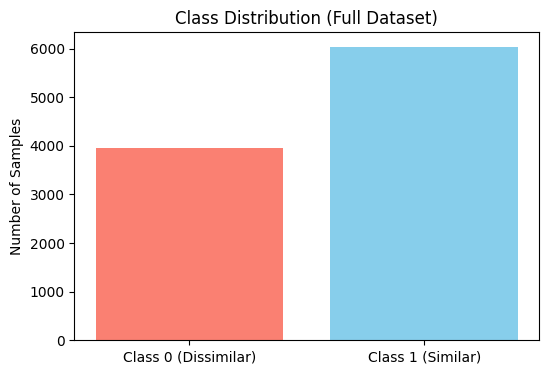

Class 0 count: 3964
Class 1 count: 6036
Class 1 proportion: 60.36%


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Compute class distribution
unique, counts = np.unique(labels.numpy(), return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar(['Class 0 (Dissimilar)', 'Class 1 (Similar)'], counts, color=['salmon', 'skyblue'])
plt.title("Class Distribution (Full Dataset)")
plt.ylabel("Number of Samples")
plt.show()

print(f"Class 0 count: {counts[0]}")
print(f"Class 1 count: {counts[1]}")
print(f"Class 1 proportion: {counts[1] / len(labels):.2%}")


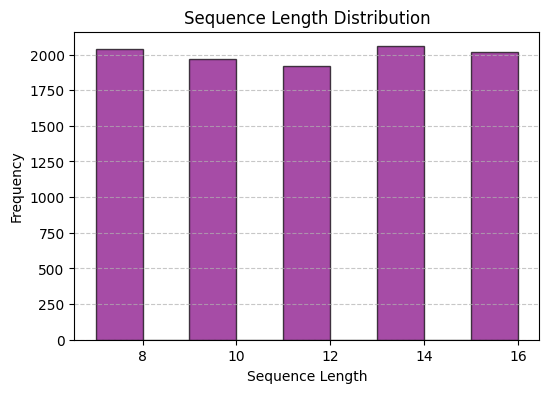

Average sequence length: 11.01
Max sequence length: 15


In [37]:
lengths = [len(seq) for seq in sequences]

plt.figure(figsize=(6, 4))
plt.hist(lengths, bins=range(min(lengths), max(lengths) + 2), color='purple', alpha=0.7, edgecolor='black')
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average sequence length: {np.mean(lengths):.2f}")
print(f"Max sequence length: {max(lengths)}")


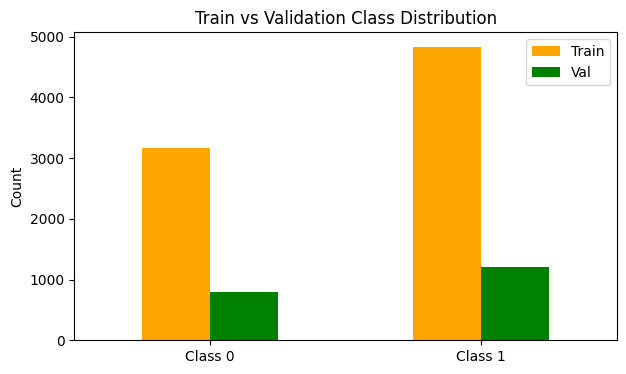

In [38]:
import pandas as pd

train_labels = y_train.numpy()
val_labels = y_val.numpy()

labels_dist = pd.DataFrame({
    'Train': [np.sum(train_labels == 0), np.sum(train_labels == 1)],
    'Val':   [np.sum(val_labels == 0),   np.sum(val_labels == 1)]
}, index=['Class 0', 'Class 1'])

labels_dist.plot(kind='bar', figsize=(7, 4), color=['orange', 'green'])
plt.title("Train vs Validation Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [39]:
print("--- Inspecting first 3 samples ---")
for i in range(3):
    seq = sequences[i]
    lbl = labels[i].item()
    
    mid = len(seq) // 2
    left  = seq[:mid]
    noise = seq[mid:mid+1]
    right = seq[mid+1:]
    
    print(f"\nSample {i+1} | Label: {lbl}")
    print(f"Left part:     {left.tolist()}")
    print(f"Noise token:   {noise.tolist()}")
    print(f"Right part:    {right.tolist()}")
    print(f"Full sequence: {seq.tolist()}")
    print("-" * 50)


--- Inspecting first 3 samples ---

Sample 1 | Label: 1
Left part:     [36, 16, 41, 46, 26]
Noise token:   [19]
Right part:    [25, 47, 41, 15, 36]
Full sequence: [36, 16, 41, 46, 26, 19, 25, 47, 41, 15, 36]
--------------------------------------------------

Sample 2 | Label: 1
Left part:     [26, 54, 55, 15, 40, 19]
Noise token:   [28]
Right part:    [19, 41, 15, 56, 54, 25]
Full sequence: [26, 54, 55, 15, 40, 19, 28, 19, 41, 15, 56, 54, 25]
--------------------------------------------------

Sample 3 | Label: 0
Left part:     [1, 16, 51, 23, 33, 44, 56]
Noise token:   [15]
Right part:    [9, 22, 45, 23, 44, 24, 8]
Full sequence: [1, 16, 51, 23, 33, 44, 56, 15, 9, 22, 45, 23, 44, 24, 8]
--------------------------------------------------


In [40]:
def init_orthogonal_lstm(model):
    """
    Apply specialized weight initialization for LSTM-based models.
    This function initializes LSTM parameters using
    strategies that help prevent vanishing/exploding gradients and
    improve convergence.

    Initialization strategy:
        • weight_hh (Hidden-to-Hidden weights)
            Initialized using Orthogonal Initialization.
            This helps preserve gradient norms across time steps and
            stabilizes long sequence training.

        • weight_ih (Input-to-Hidden weights)
            Initialized using Xavier (Glorot) Uniform initialization.
            This keeps the variance of activations stable across layers.

        • bias terms
            Initialized to zero for neutral starting conditions.
    """

    for name, param in model.named_parameters():

        # Hidden-to-hidden recurrent weights of LSTM
        if "weight_hh" in name:
            nn.init.orthogonal_(param)

        # Input-to-hidden weights
        elif "weight_ih" in name:
            nn.init.xavier_uniform_(param)

        # Bias terms for LSTM gates
        elif "bias" in name:
            nn.init.zeros_(param)


In [41]:
vocab_size = 60
embedding_dim = 64
hidden_dim = 128
num_layers = 3
num_classes = 2

model = RobustBiLSTM(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=0.3
)

In [42]:

init_orthogonal_lstm(model)


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.to(device)

num_epochs = 20
max_grad_norm = 4.0

In [44]:
def detach_hidden(hidden):
    if hidden is None:
        return None
    return tuple(h.detach() for h in hidden)


In [45]:
import time
import torch.nn.utils as utils

train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):

    start_time = time.time()

    model.train()

    running_train_loss = 0.0
    hidden = None 
    for batch_idx, (x, lengths, y) in enumerate(train_loader, 1):

        x = x.to(device)
        y = y.to(device)
        lengths = lengths.cpu()

        optimizer.zero_grad()
        hidden = detach_hidden(hidden)
        logits, hidden = model(x, lengths,hidden)
        loss = criterion(logits, y)

        loss.backward()

        utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for x, lengths, y in val_loader:

            x = x.to(device)
            y = y.to(device)
            lengths = lengths.cpu()

            logits,_ = model(x, lengths, hidden=None)
            loss = criterion(logits, y)

            running_val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_acc = 100.0 * correct / total
    elapsed = time.time() - start_time

    print("=" * 80)
    print(f"Epoch {epoch}/{num_epochs}")
    print(f"Train Loss      : {avg_train_loss:.4f}")
    print(f"Validation Loss : {avg_val_loss:.4f}")
    print(f"Validation Acc  : {val_acc:.2f}%")
    print(f"Epoch Time      : {elapsed:.2f} sec")
    print("=" * 80)


Epoch 1/20
Train Loss      : 0.6746
Validation Loss : 0.6594
Validation Acc  : 60.35%
Epoch Time      : 22.28 sec
Epoch 2/20
Train Loss      : 0.5045
Validation Loss : 0.3456
Validation Acc  : 85.65%
Epoch Time      : 24.21 sec
Epoch 3/20
Train Loss      : 0.2905
Validation Loss : 0.2062
Validation Acc  : 93.15%
Epoch Time      : 26.52 sec
Epoch 4/20
Train Loss      : 0.2109
Validation Loss : 0.1909
Validation Acc  : 93.85%
Epoch Time      : 24.23 sec
Epoch 5/20
Train Loss      : 0.1807
Validation Loss : 0.1920
Validation Acc  : 93.95%
Epoch Time      : 21.12 sec
Epoch 6/20
Train Loss      : 0.1621
Validation Loss : 0.2035
Validation Acc  : 93.40%
Epoch Time      : 23.23 sec
Epoch 7/20
Train Loss      : 0.1411
Validation Loss : 0.1844
Validation Acc  : 94.05%
Epoch Time      : 27.21 sec
Epoch 8/20
Train Loss      : 0.1292
Validation Loss : 0.1710
Validation Acc  : 94.30%
Epoch Time      : 34.76 sec
Epoch 9/20
Train Loss      : 0.1181
Validation Loss : 0.1693
Validation Acc  : 94.35%
Ep

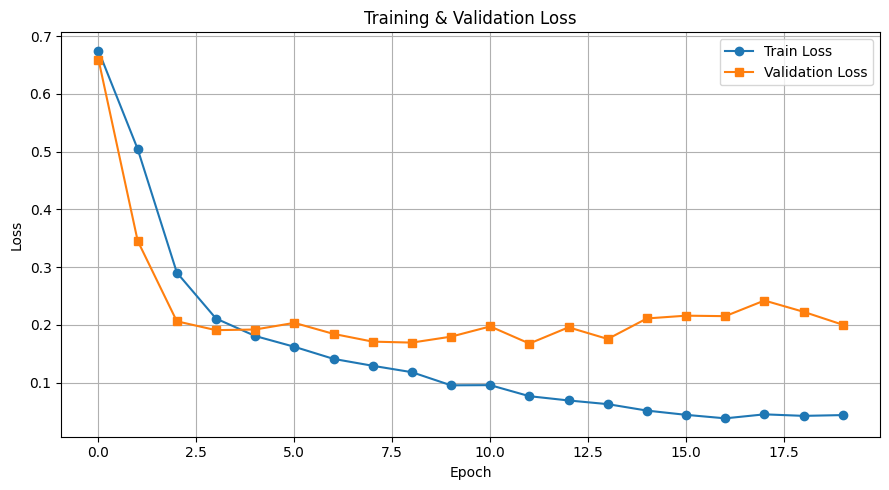

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()